In [ ]:
import numpy as np 
import matplotlib.pyplot as plt 

from glob import glob 
from astropy.io import fits 

from scipy.stats import mode as spmode
%matplotlib inline

In [ ]:
print(glob('dark/*.fits')[::61]) 

['dark\\dark_10s-01.fits', 'dark\\dark_3s-01.fits']


In [ ]:
# Start by getting a list of the 10-second darks
filenames = glob('dark/dark_10s-*.fits')
filenames = sorted(filenames) 
print(len(filenames)) # there are 61 files
print(filenames[:3]) # see what the first three filenames look like

61
['dark\\dark_10s-01.fits', 'dark\\dark_10s-02.fits', 'dark\\dark_10s-03.fits']


In [ ]:

header = fits.getheader(filenames[0])
print(fits.getdata(filenames[0], header=True))
header

(array([[1113, 1096, 1105, ..., 1086, 1145, 1098],
       [1133, 1081, 1095, ..., 1127, 1072, 1104],
       [1084, 1079, 1100, ..., 1114, 1117, 1129],
       ...,
       [1101, 1108, 1071, ..., 1092, 1132, 1112],
       [1040, 1059, 1118, ..., 1093, 1055, 1120],
       [1118, 1069, 1107, ..., 1097, 1113, 1132]],
      shape=(256, 256), dtype=uint16), SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                   16 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  256                                                  
NAXIS2  =                  256                                                  
EXPTIME =                   10 / exposure time                                  
DATE-OBS= '2016-10-31T21:55:00' / date of the observation                       
OBJECT  = 'Dark    '           / name of observed object                        

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                   16 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  256                                                  
NAXIS2  =                  256                                                  
EXPTIME =                   10 / exposure time                                  
DATE-OBS= '2016-10-31T21:55:00' / date of the observation                       
OBJECT  = 'Dark    '           / name of observed object                        
RA_OBJ  = '' / R.A. of the observation                                          
DEC_OBJ = '' / declination of the observed object                               
OBSERVER= 'ZPV     '           / observer who acquired the data                 
TELESCOP= 'McDonald 2.1m'      / name of telescope                              
INSTRUME= 'ProEM   '        

<class 'numpy.ndarray'>
(256, 256)


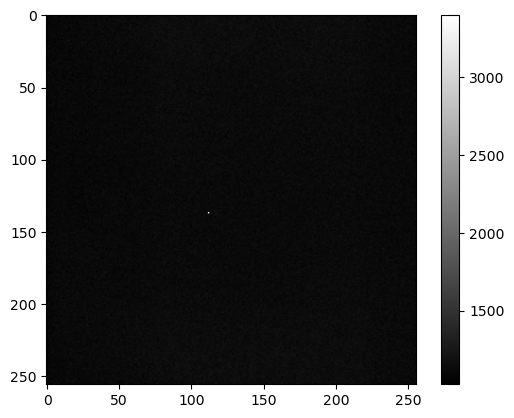

In [ ]:

data = fits.getdata(filenames[0])

print(type(data)) 
print(data.shape) # the image is 256 x 256 pixels

# Display the image.
plt.imshow(data,cmap='gray')
plt.colorbar()
plt.show()

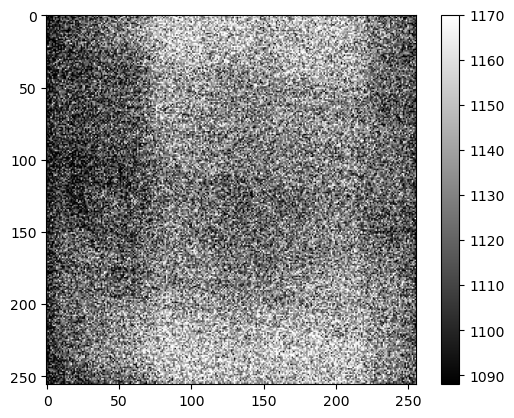

In [24]:
# Define new image display function
def display(data): 
    plt.imshow(data,cmap='gray',vmin=np.percentile(data,5),vmax=np.percentile(data,95))
    plt.colorbar()
    plt.show()

#Display the first 10-second dark again:
display(data)

In [ ]:

#characterize these image values in numerous ways:
print('Min:',np.min(data))
print('Max:',np.max(data))
print('Mean:',np.mean(data))
print('Median:',np.median(data))
print('Stddev:',np.std(data))

Min: 1027
Max: 3404
Mean: 1128.9493865966797
Median: 1129.0
Stddev: 26.380332694147587


In [ ]:
from numpy import size

def mode(a):
    x = spmode(a,axis=None).mode
    if len(x.shape) == 1:
        x=x[0]
    return x

print('Mode:',mode(data))

Mode: 1129


<class 'numpy.ndarray'> (61, 256, 256)


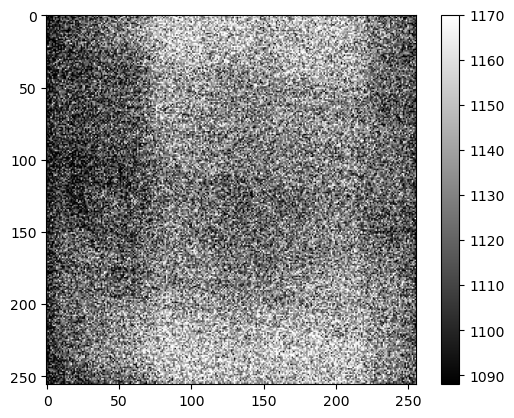

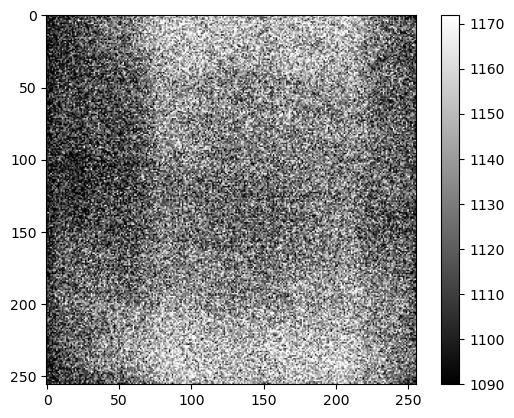

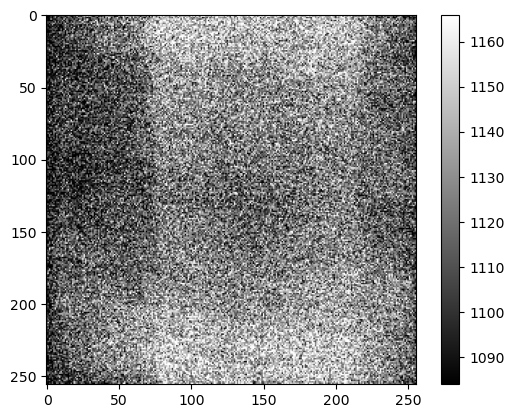

1128.9493865966797 1130.8819122314453 1124.5913391113281


In [ ]:
# First, create an empty numpy array of size 61x256x256 
# to hold all the data. 

datastack = np.zeros((61,256,256))
print(type(datastack),datastack.shape)

# Then loop through all the filenames and set each "slice" 
# of the datastack to the individual image data.

for i,filename in enumerate(filenames):
    datastack[i] = fits.getdata(filename)

# datastack now contains all the 10-second dark data.
# verify by displaying a few frames:

display(datastack[0])
display(datastack[1])
display(datastack[2])

# Each is slightly different, but they look generally 
# similar since they contain the same sources of noise. 
# combine so many frames to "average" over the 
# random differences in individual images to get a more 
# representative calibration.

print(np.mean(datastack[0]),np.mean(datastack[1]),np.mean(datastack[2]))

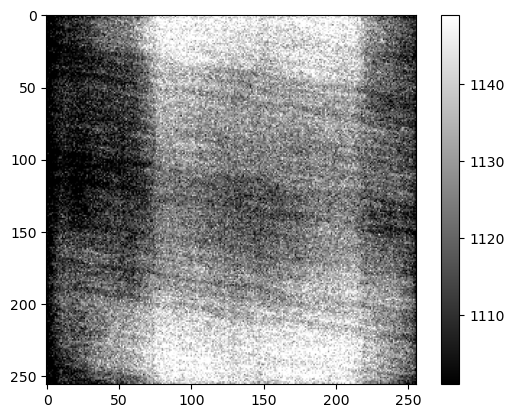

Mean: 1125.3980255126953


In [ ]:
# finally compute the master 10-second dark 
# calibration.

masterdark_10s = np.median(datastack,axis=0)
display(masterdark_10s)
print('Mean:',np.mean(masterdark_10s))

In [ ]:
newheader = header.copy()
newheader['COMMENT'] = "master 10-second dark"
newheader['COMMENT'] = str(len(filenames))+" frames median combined"
newheader['COMMENT'] = "processed by Yuchen Tian"

newheader

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                   16 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  256                                                  
NAXIS2  =                  256                                                  
EXPTIME =                   10 / exposure time                                  
DATE-OBS= '2016-10-31T21:55:00' / date of the observation                       
OBJECT  = 'Dark    '           / name of observed object                        
RA_OBJ  = '' / R.A. of the observation                                          
DEC_OBJ = '' / declination of the observed object                               
OBSERVER= 'ZPV     '           / observer who acquired the data                 
TELESCOP= 'McDonald 2.1m'      / name of telescope                              
INSTRUME= 'ProEM   '        

In [31]:
# Finally, write it out to a FITS file:

fits.writeto("MasterDark_10s.fits",masterdark_10s,newheader,overwrite=True)

['dark\\dark_3s-01.fits', 'dark\\dark_3s-02.fits', 'dark\\dark_3s-03.fits', 'dark\\dark_3s-04.fits', 'dark\\dark_3s-05.fits', 'dark\\dark_3s-06.fits', 'dark\\dark_3s-07.fits', 'dark\\dark_3s-08.fits', 'dark\\dark_3s-09.fits', 'dark\\dark_3s-10.fits', 'dark\\dark_3s-11.fits', 'dark\\dark_3s-12.fits', 'dark\\dark_3s-13.fits', 'dark\\dark_3s-14.fits', 'dark\\dark_3s-15.fits', 'dark\\dark_3s-16.fits', 'dark\\dark_3s-17.fits', 'dark\\dark_3s-18.fits', 'dark\\dark_3s-19.fits', 'dark\\dark_3s-20.fits', 'dark\\dark_3s-21.fits', 'dark\\dark_3s-22.fits', 'dark\\dark_3s-23.fits', 'dark\\dark_3s-24.fits', 'dark\\dark_3s-25.fits', 'dark\\dark_3s-26.fits', 'dark\\dark_3s-27.fits', 'dark\\dark_3s-28.fits', 'dark\\dark_3s-29.fits', 'dark\\dark_3s-30.fits', 'dark\\dark_3s-31.fits', 'dark\\dark_3s-32.fits', 'dark\\dark_3s-33.fits', 'dark\\dark_3s-34.fits', 'dark\\dark_3s-35.fits', 'dark\\dark_3s-36.fits', 'dark\\dark_3s-37.fits', 'dark\\dark_3s-38.fits', 'dark\\dark_3s-39.fits', 'dark\\dark_3s-40.fits',

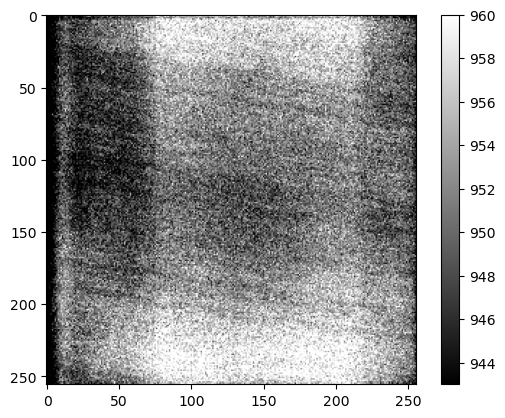

Mean: 951.7710571289062


In [ ]:
filenames = glob('dark/dark_3s-*.fits')
filenames = sorted(filenames)
print(filenames)

datastack = np.zeros((61,256,256))
for i,filename in enumerate(filenames):
    datastack[i] = fits.getdata(filename)

masterdark_3s = np.median(datastack,axis=0)
display(masterdark_3s)
print('Mean:',np.mean(masterdark_3s))


newheader = header.copy()
newheader['COMMENT'] = "master 3-second dark"
newheader['COMMENT'] = str(len(filenames))+" frames median combined"
newheader['COMMENT'] = "processed by Yuchen Tian"

fits.writeto("MasterDark_3s.fits",masterdark_3s,newheader,overwrite=True)

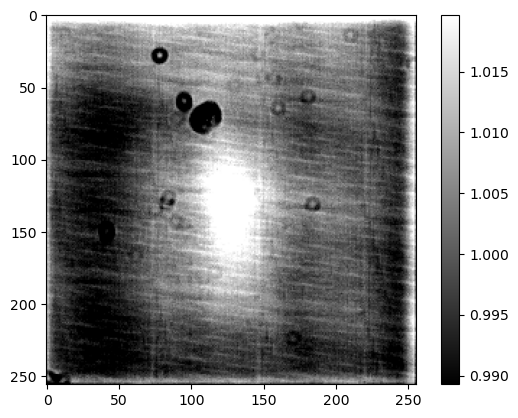

Mean: 1.0019265986265316


In [ ]:

filenames = glob('flat/dome_flat_*.fits')
header = fits.getheader(filenames[i])

datastack = np.zeros((61,256,256))
for i,filename in enumerate(filenames):
    # print(fits.getheader(filename).get('EXPTIME'))
    datastack[i] = fits.getdata(filename) - fits.getdata('MasterDark_3s.fits')
    datastack[i] /= mode(datastack[i])

masterflat_3s = np.median(datastack,axis=0)
display(masterflat_3s)
print('Mean:',np.mean(masterflat_3s))


newheader = header.copy()
newheader['COMMENT'] = "master 3-second flat"
newheader['COMMENT'] = str(len(filenames))+" frames median combined"
newheader['COMMENT'] = "processed by Yuchen Tian"

fits.writeto("MasterFlat.fits",masterflat_3s,newheader,overwrite=True)


In [ ]:

filenames = glob('ktwo220274129/*[0-9].fits')
header = fits.getheader(filenames[0])

for i,filename in enumerate(filenames):
    # print(fits.getheader(filename).get('EXPTIME'))
    temp_data = fits.getdata(filename) - fits.getdata('MasterDark_10s.fits')
    temp_data /= fits.getdata('MasterFlat.fits')
    newheader = header.copy()
    newheader['COMMENT'] = "processed by Yuchen Tian"
    filename_temp = filenames[i].split('.')
    fits.writeto(filename_temp[0] + 'c.fits',temp_data,newheader,overwrite=True)
new_filenames = glob('ktwo220274129/*c.fits')


ktwo220274129\ktwo220274129-0001c.fits ktwo220274129\ktwo220274129-0001.fits


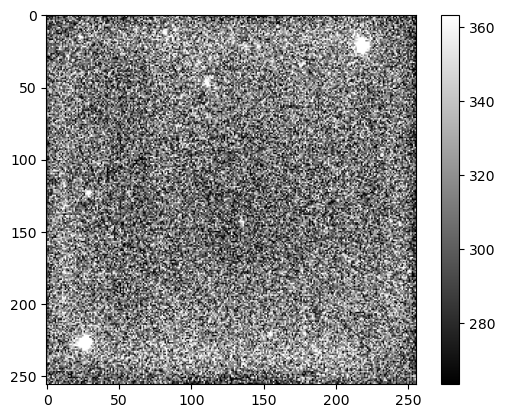

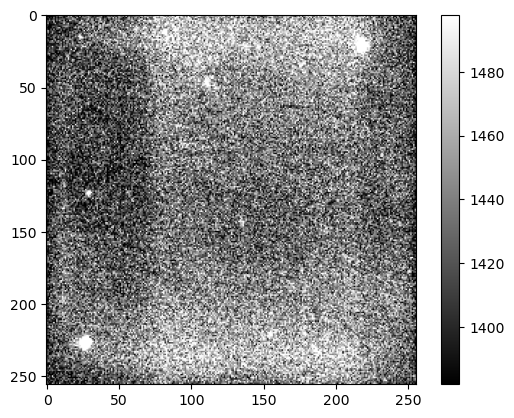

In [35]:
print(new_filenames[0],filenames[0])
display(fits.getdata(new_filenames[0]))
display(fits.getdata(filenames[0]))
